#similarly unlike the other cenarios here also we have the nodes having the values and the edges having the relationship and then with that relationship finding the correct api.

#The atom of data in a Knowledge Graph is the Triple. Every complex graph is built by combining these three-part statements:

       (Subject)---------->(Object)


In [2]:
import networkx as nx#actually required for c reating the graph 

print(nx.__version__)#checking the version for finding whether it is installed or not

3.1


In [5]:
import networkx as nx

G = nx.DiGraph()#directed graph creation function

print(type(G))#preparing of the default structure of the knowledge graph first

<class 'networkx.classes.digraph.DiGraph'>


In [6]:
#adding of the first api
G.add_node("WeatherAPI")

print(G.nodes())#a entity is represented

['WeatherAPI']


In [7]:
G.add_node("CurrentWeather")#more nodes are added
G.add_node("city")

print(list(G.nodes()))

['WeatherAPI', 'CurrentWeather', 'city']


In [8]:
G.add_edge(
    "WeatherAPI",
    "CurrentWeather",
    relation="has_endpoint"
)

G.add_edge(
    "CurrentWeather",
    "city",
    relation="requires"
)#the relationships are loaded mfor the directed graph formation

In [9]:
print(G.edges(data=True))#for viewing the relationships

[('WeatherAPI', 'CurrentWeather', {'relation': 'has_endpoint'}), ('CurrentWeather', 'city', {'relation': 'requires'})]


In [10]:
for source,target,data in G.edges(data=True):
    print(source,data["relation"],target)#this is how the agent will read the graph 

WeatherAPI has_endpoint CurrentWeather
CurrentWeather requires city


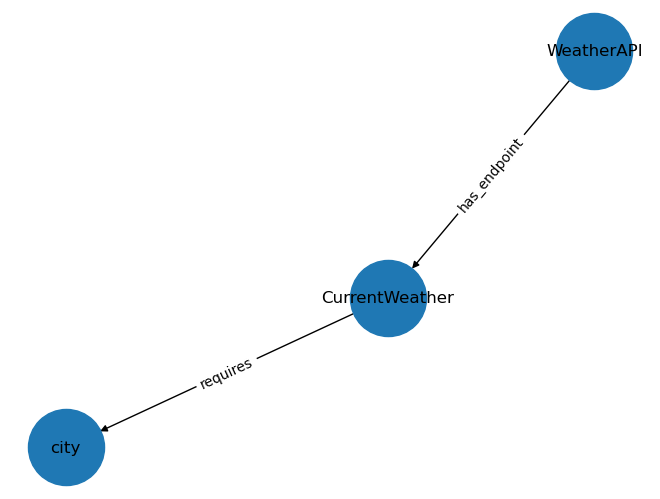

In [11]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000
)

edge_labels = nx.get_edge_attributes(
    G,
    "relation"
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.show()

In [12]:
G = nx.DiGraph()

triples = [

("WeatherAPI","belongs_to","Weather"),
("WeatherAPI","has_endpoint","CurrentWeather"),
("CurrentWeather","requires","city"),
("CurrentWeather","returns","temperature"),

("MapsAPI","belongs_to","Maps"),
("MapsAPI","has_endpoint","Location"),
("Location","requires","place"),
("Location","returns","coordinates"),

("NewsAPI","belongs_to","News"),
("NewsAPI","has_endpoint","Headlines"),
("Headlines","returns","news")

]

for s,r,o in triples:
    G.add_edge(
        s,
        o,
        relation=r
    )

In [13]:
print("Nodes:")
print(list(G.nodes()))

print("\nEdges:")
print(list(G.edges(data=True)))

Nodes:
['WeatherAPI', 'Weather', 'CurrentWeather', 'city', 'temperature', 'MapsAPI', 'Maps', 'Location', 'place', 'coordinates', 'NewsAPI', 'News', 'Headlines', 'news']

Edges:
[('WeatherAPI', 'Weather', {'relation': 'belongs_to'}), ('WeatherAPI', 'CurrentWeather', {'relation': 'has_endpoint'}), ('CurrentWeather', 'city', {'relation': 'requires'}), ('CurrentWeather', 'temperature', {'relation': 'returns'}), ('MapsAPI', 'Maps', {'relation': 'belongs_to'}), ('MapsAPI', 'Location', {'relation': 'has_endpoint'}), ('Location', 'place', {'relation': 'requires'}), ('Location', 'coordinates', {'relation': 'returns'}), ('NewsAPI', 'News', {'relation': 'belongs_to'}), ('NewsAPI', 'Headlines', {'relation': 'has_endpoint'}), ('Headlines', 'news', {'relation': 'returns'})]


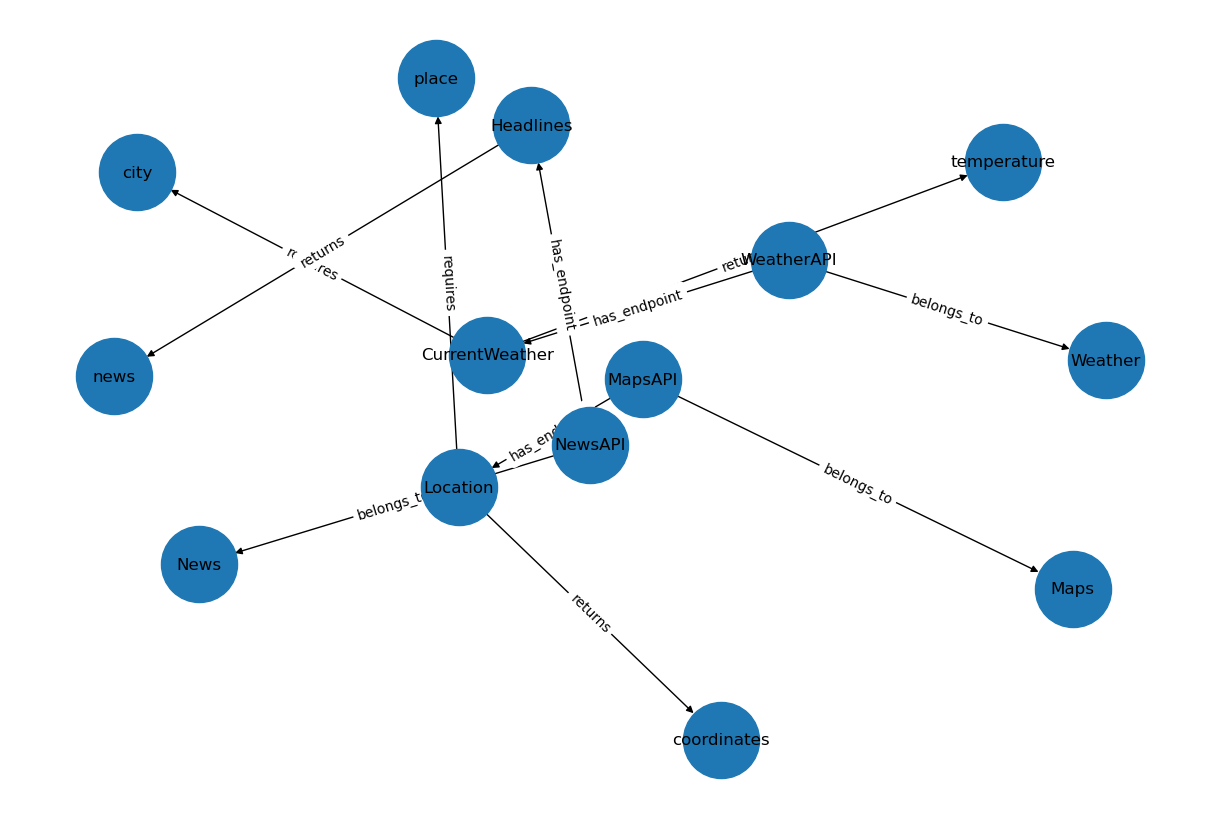

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

pos = nx.spring_layout(#decides where should each node be placed on the screen
    G,
    k=1,
    seed=42
)

nx.draw(
    G,
    pos,
    with_labels=True,#prints the graph labels on the nodes
    node_size=3000
)

edge_labels = nx.get_edge_attributes(
    G,
    "relation"
)

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.show()

In [15]:
#suppose a question is asked that which api can produce weather information then:
intent = "Weather"
for source,target,data in G.edges(data=True):

    if data["relation"]=="belongs_to":#for checking purpose mentioning it
        if target=="Weather":#check if the target asked for belongs to the weather category

            print("API Found:", source)#the required api will be found from the 25-50 Api's available this will help in finding out the required api


API Found: WeatherAPI


In [17]:
for source,target,data in G.edges(data=True):#relation exists

    if source=="WeatherAPI":

        if data["relation"]=="has_endpoint":#here printing the target

            print("Endpoint:", target)

Endpoint: CurrentWeather


In [18]:
for source,target,data in G.edges(data=True):

    if source=="CurrentWeather":

        if data["relation"]=="requires":

            print("Required Parameter:", target)#for finding the target value when the relation is given and the source is also mentioned

Required Parameter: city


In [19]:
#Application:Building a simple agent for doing this task 
def discover_api(intent):

    for source,target,data in G.edges(data=True):

        if data["relation"]=="belongs_to":

            if target.lower()==intent.lower():

                return source

    return "No API Found"

In [20]:
print(discover_api("Weather"))

WeatherAPI


In [21]:
print(discover_api("Maps"))

MapsAPI


In [22]:
def discover_endpoint(api_name):

    for source,target,data in G.edges(data=True):

        if source==api_name:

            if data["relation"]=="has_endpoint":

                return target

    return None

In [23]:
api = discover_api("Weather")#this is how the values are derived and they run

endpoint = discover_endpoint(api)#gets the value from the api

print(endpoint)

CurrentWeather


In [28]:
def discover_parameter(endpoint):

    for source,target,data in G.edges(data=True):

        if source==endpoint:

            if data["relation"]=="requires":

                return target

    return None

In [29]:
parameter = discover_parameter(
    "CurrentWeather"
)

print(parameter)

city


In [27]:
intent = "Weather"

api = discover_api(intent)

endpoint = discover_endpoint(api)

parameter = discover_parameter(endpoint)

print("API:", api)
print("Endpoint:", endpoint)
print("Parameter:", parameter)

API: WeatherAPI
Endpoint: CurrentWeather
Parameter: city


In [28]:
question = "What is the weather in Kolkata?"

print(question)

What is the weather in Kolkata?


In [29]:
def extract_intent(question):

    question = question.lower()

    if "weather" in question:
        return "Weather"

    elif "map" in question:
        return "Maps"

    elif "news" in question:
        return "News"

    else:
        return None

In [30]:
intent = extract_intent(
    "What is the weather in Kolkata?"
)
#just for these few examples finding the api from the source data or endoint
print(intent)

Weather


In [31]:
def extract_city(question):

    words = question.split()

    return words[-1].replace("?","")

In [34]:
city = extract_city(
    "What is the weather in Kolkata?"
)

print(city)

Kolkata


In [35]:
question = "What is the weather in Kolkata?"

intent = extract_intent(question)

api = discover_api(intent)

endpoint = discover_endpoint(api)

parameter = discover_parameter(endpoint)

city = extract_city(question)

print("Intent:", intent)
print("API:", api)
print("Endpoint:", endpoint)
print("Parameter:", parameter)
print("Value:", city)
#the final discovery of all the required details for finding the values is taking place

Intent: Weather
API: WeatherAPI
Endpoint: CurrentWeather
Parameter: city
Value: Kolkata
